In [ ]:
!pip install kagglehub pandas nltk wordcloud

In [ ]:
import re
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from textblob import TextBlob

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [ ]:
# ------------------ LOAD DATA ------------------
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "sentimentdataset.csv"
df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "kashishparmar02/social-media-sentiments-analysis-dataset", file_path)

<ipython-input-72-b14ca9284643>:6: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "kashishparmar02/social-media-sentiments-analysis-dataset", file_path)


In [ ]:
# Drop unnecessary columns
df = df.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'], errors='ignore')

# Convert timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Clean text data
def clean_text(text):
    text = str(text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove user @ references and '#' from hashtags
    text = re.sub(r'\@\w+|\#', '', text)
    # Remove special characters
    text = re.sub(r'[^A-Za-z0-9\s]+', '', text)
    return text.lower().strip()

df['cleaned_text'] = df['Text'].apply(clean_text)

# Show cleaned sample
print("\nCleaned text sample:")
print(df[['Text', 'cleaned_text']].head())


Cleaned text sample:
                                                Text  \
0   Enjoying a beautiful day at the park!        ...   
1   Traffic was terrible this morning.           ...   
2   Just finished an amazing workout! 💪          ...   
3   Excited about the upcoming weekend getaway!  ...   
4   Trying out a new recipe for dinner tonight.  ...   

                                 cleaned_text  
0        enjoying a beautiful day at the park  
1           traffic was terrible this morning  
2            just finished an amazing workout  
3  excited about the upcoming weekend getaway  
4  trying out a new recipe for dinner tonight  


In [ ]:
# Feature engineering
df['Engagement'] = df['Likes'].fillna(0) + df['Retweets'].fillna(0)
df['Date'] = df['Timestamp'].dt.date
df['Hour'] = df['Timestamp'].dt.hour
df['Weekday'] = df['Timestamp'].dt.day_name()

In [ ]:
from textblob import TextBlob

def categorize_sentiment(text):
    analysis = TextBlob(str(text))
    # Classify based on polarity score
    if analysis.sentiment.polarity > 0.05:
        return "Positive"
    elif analysis.sentiment.polarity < -0.05:
        return "Negative"
    else:
        return "Neutral"

df['Sentiment_3cat'] = df['Text'].apply(categorize_sentiment)

In [ ]:
# Initial inspection
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
Text              0
Sentiment         0
Timestamp         0
User              0
Platform          0
Hashtags          0
Retweets          0
Likes             0
Country           0
Year              0
Month             0
Day               0
Hour              0
cleaned_text      0
Engagement        0
Date              0
Weekday           0
Sentiment_3cat    0
dtype: int64


In [ ]:
df.columns

Index(['Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags',
       'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour',
       'cleaned_text', 'Engagement', 'Date', 'Weekday', 'Sentiment_3cat'],
      dtype='object')

In [ ]:
# Sentiment count
sentiment_counts = df['Sentiment'].value_counts()
print(sentiment_counts)

Sentiment
Positive               44
Joy                    42
Excitement             32
Happy                  14
Neutral                14
                       ..
Vibrancy                1
Culinary Adventure      1
Mesmerizing             1
Thrilling Journey       1
Winter Magic            1
Name: count, Length: 279, dtype: int64


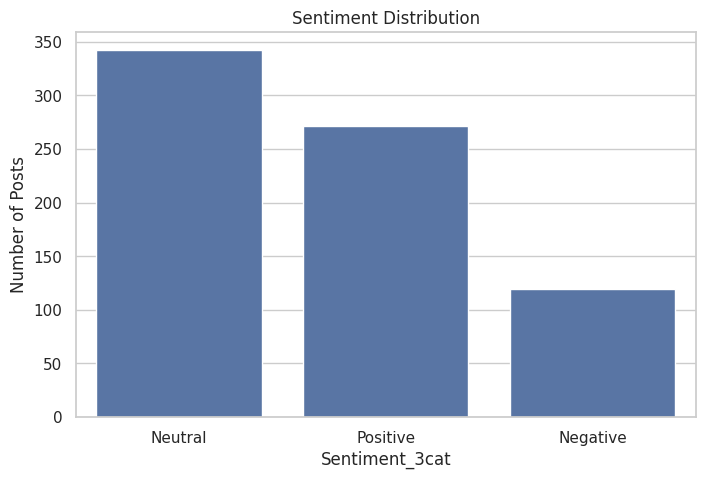


Sentiment distribution (%):
Sentiment
Positive               6.0
Joy                    5.7
Excitement             4.4
Happy                  1.9
Neutral                1.9
                      ... 
Vibrancy               0.1
Culinary Adventure     0.1
Mesmerizing            0.1
Thrilling Journey      0.1
Winter Magic           0.1
Name: proportion, Length: 279, dtype: float64


In [ ]:
# Count sentiment distribution
sentiment_counts = df['Sentiment_3cat'].value_counts()

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
plt.title("Sentiment Distribution")
plt.ylabel("Number of Posts")
plt.show()

# Show percentage breakdown
print("\nSentiment distribution (%):")
print((df['Sentiment'].value_counts(normalize=True) * 100).round(1))

In [ ]:
df

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,cleaned_text,Engagement,Date,Weekday,Sentiment_3cat
0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12,enjoying a beautiful day at the park,45.0,2023-01-15,Sunday,Positive
1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8,traffic was terrible this morning,15.0,2023-01-15,Sunday,Negative
2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15,just finished an amazing workout,60.0,2023-01-15,Sunday,Positive
3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18,excited about the upcoming weekend getaway,23.0,2023-01-15,Sunday,Positive
4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19,trying out a new recipe for dinner tonight,37.0,2023-01-15,Sunday,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,Collaborating on a science project that receiv...,Happy,2017-08-18 18:20:00,ScienceProjectSuccessHighSchool,Facebook,#ScienceFairWinner #HighSchoolScience,20.0,39.0,UK,2017,8,18,18,collaborating on a science project that receiv...,59.0,2017-08-18,Friday,Positive
728,Attending a surprise birthday party organized ...,Happy,2018-06-22 14:15:00,BirthdayPartyJoyHighSchool,Instagram,#SurpriseCelebration #HighSchoolFriendship,25.0,48.0,USA,2018,6,22,14,attending a surprise birthday party organized ...,73.0,2018-06-22,Friday,Positive
729,Successfully fundraising for a school charity ...,Happy,2019-04-05 17:30:00,CharityFundraisingTriumphHighSchool,Twitter,#CommunityGiving #HighSchoolPhilanthropy,22.0,42.0,Canada,2019,4,5,17,successfully fundraising for a school charity ...,64.0,2019-04-05,Friday,Positive
730,"Participating in a multicultural festival, cel...",Happy,2020-02-29 20:45:00,MulticulturalFestivalJoyHighSchool,Facebook,#CulturalCelebration #HighSchoolUnity,21.0,43.0,UK,2020,2,29,20,participating in a multicultural festival cele...,64.0,2020-02-29,Saturday,Positive


<Axes: title={'center': 'Sentiment by Hour'}, xlabel='Hour'>

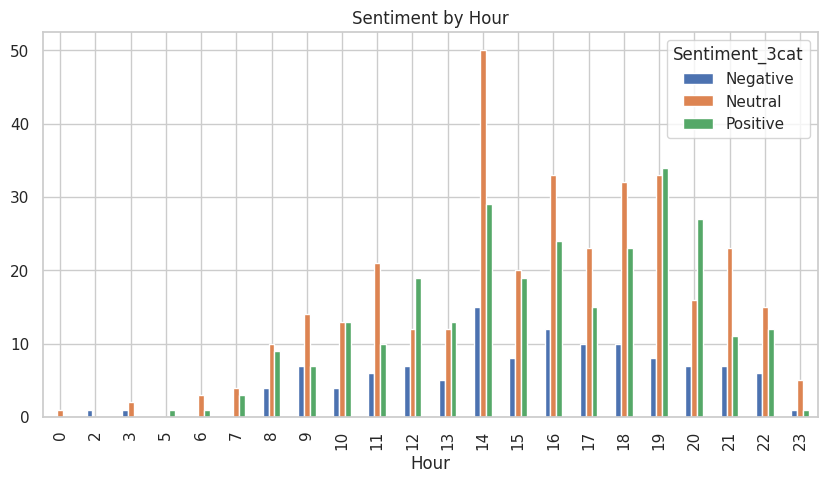

In [ ]:
hourly_sentiment = df.groupby(['Hour', 'Sentiment_3cat']).size().unstack().fillna(0)
hourly_sentiment.plot(kind='bar', title='Sentiment by Hour', figsize=(10,5))

In [ ]:
from collections import Counter

# Flatten hashtag lists
hashtags = df['Hashtags'].dropna().astype(str).str.split()
flat_hashtags = [tag.lower().strip('#') for sublist in hashtags for tag in sublist]

# Count
top_hashtags = Counter(flat_hashtags).most_common(10)
print(top_hashtags)

# Convert to DataFrame for dashboard use
hashtag_df = pd.DataFrame(top_hashtags, columns=['Hashtag', 'Count'])

[('serenity', 15), ('gratitude', 13), ('excitement', 13), ('despair', 11), ('nostalgia', 11), ('contentment', 10), ('curiosity', 10), ('awe', 9), ('grief', 9), ('loneliness', 9)]


<ipython-input-83-bff97ef57d0d>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_sentiments.index, x=top_sentiments.values, palette='plasma')


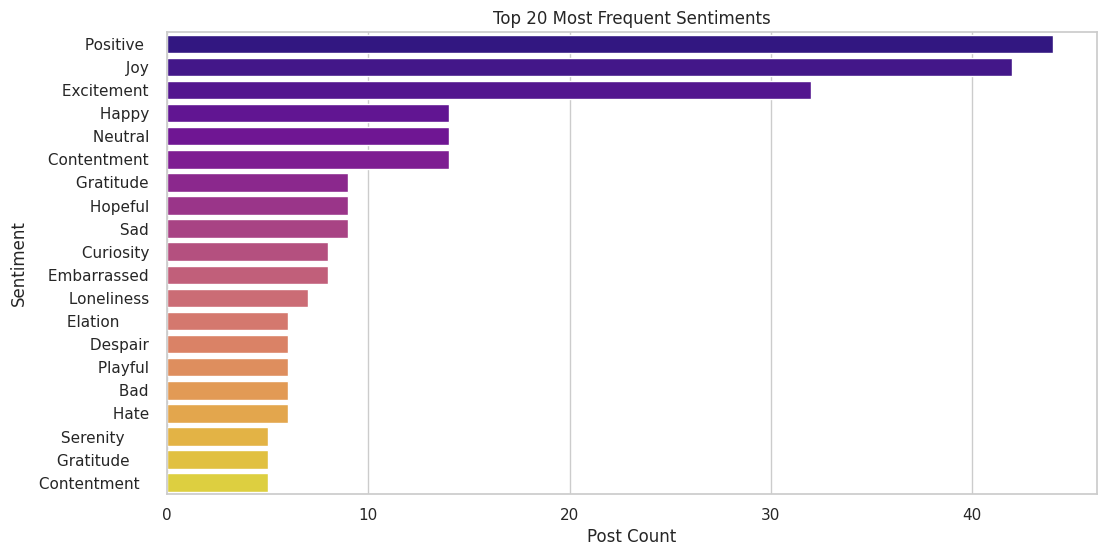

In [ ]:
# -------------------------------
# 1. Sentiment Frequency (Top 20)
# -------------------------------
top_sentiments = df['Sentiment'].value_counts().nlargest(20)
sns.barplot(y=top_sentiments.index, x=top_sentiments.values, palette='plasma')
plt.title("Top 20 Most Frequent Sentiments")
plt.xlabel("Post Count")
plt.show()

<ipython-input-84-86de6a7f534d>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_engage.index, x=top_engage.values, palette='inferno')


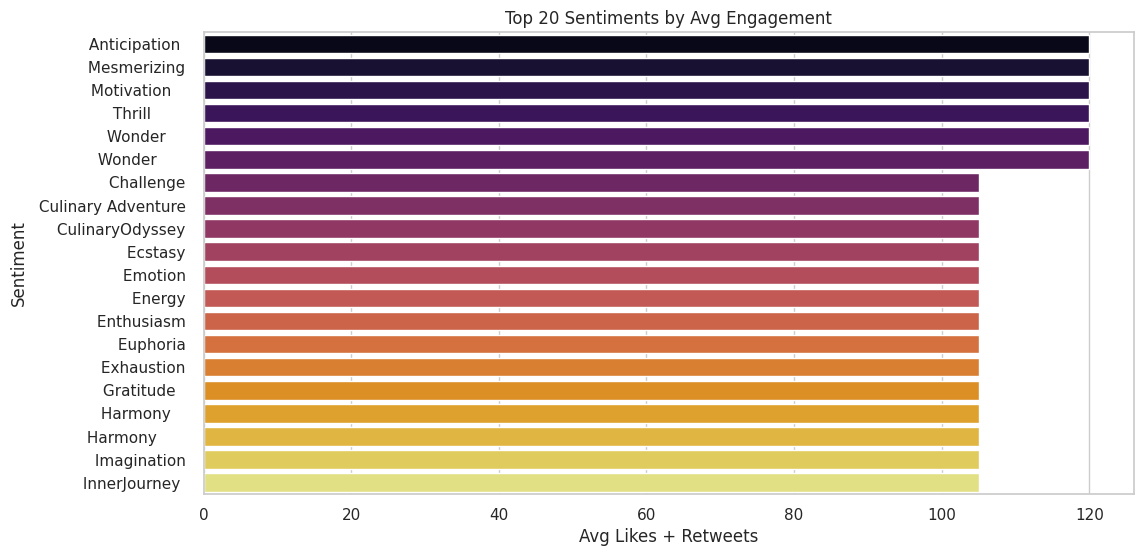

In [ ]:
# -------------------------------
# 2. Average Engagement by Top 20 Sentiments
# -------------------------------
top_engage = df.groupby('Sentiment')['Engagement'].mean().nlargest(20)
sns.barplot(y=top_engage.index, x=top_engage.values, palette='inferno')
plt.title("Top 20 Sentiments by Avg Engagement")
plt.xlabel("Avg Likes + Retweets")
plt.show()

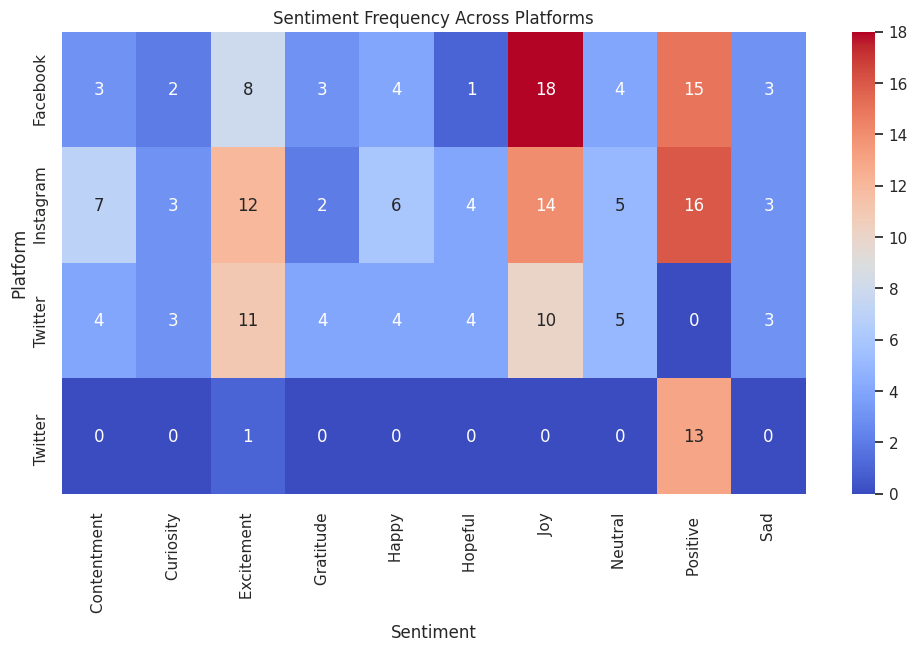

In [ ]:
# -------------------------------
# 3. Sentiment Heatmap Across Platforms (Top 10 Sentiments)
# -------------------------------
top_10_sent = df['Sentiment'].value_counts().nlargest(10).index
heat_df = df[df['Sentiment'].isin(top_10_sent)].groupby(['Platform', 'Sentiment']).size().unstack().fillna(0)
sns.heatmap(heat_df, annot=True, fmt='g', cmap='coolwarm')
plt.title("Sentiment Frequency Across Platforms")
plt.show()

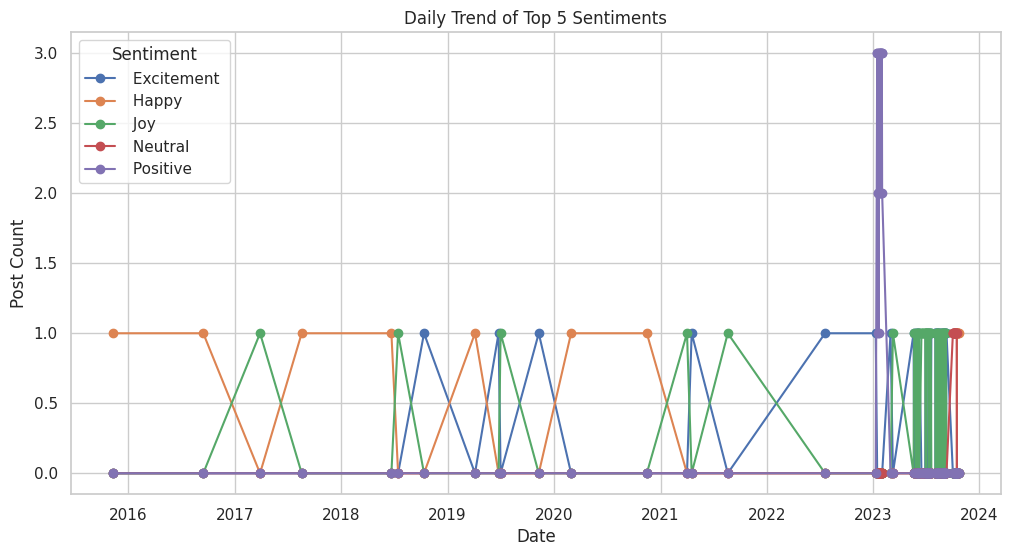

In [ ]:
# -------------------------------
# 4. Daily Sentiment Trend (Top 5)
# -------------------------------
top_5 = df['Sentiment'].value_counts().nlargest(5).index
trend_df = df[df['Sentiment'].isin(top_5)]
trend_pivot = trend_df.groupby(['Date', 'Sentiment']).size().unstack().fillna(0)
trend_pivot.plot(marker='o')
plt.title("Daily Trend of Top 5 Sentiments")
plt.ylabel("Post Count")
plt.grid(True)
plt.show()

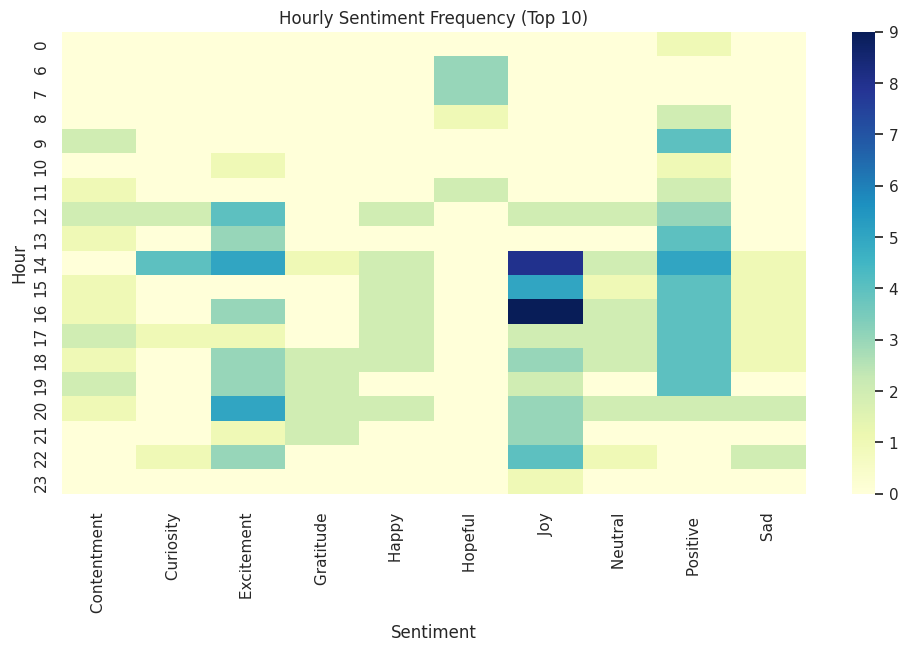

In [ ]:
# -------------------------------
# 5. Sentiment by Hour Heatmap (Top 10)
# -------------------------------
hour_sent_df = df[df['Sentiment'].isin(top_10_sent)]
hourly = hour_sent_df.groupby(['Hour', 'Sentiment']).size().unstack().fillna(0)
sns.heatmap(hourly, cmap='YlGnBu', annot=False)
plt.title("Hourly Sentiment Frequency (Top 10)")
plt.ylabel("Hour")
plt.show()

<ipython-input-88-5230c2bbca3b>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=filtered, x='Engagement', y='Sentiment', alpha=0.5, jitter=True, palette='Set3')


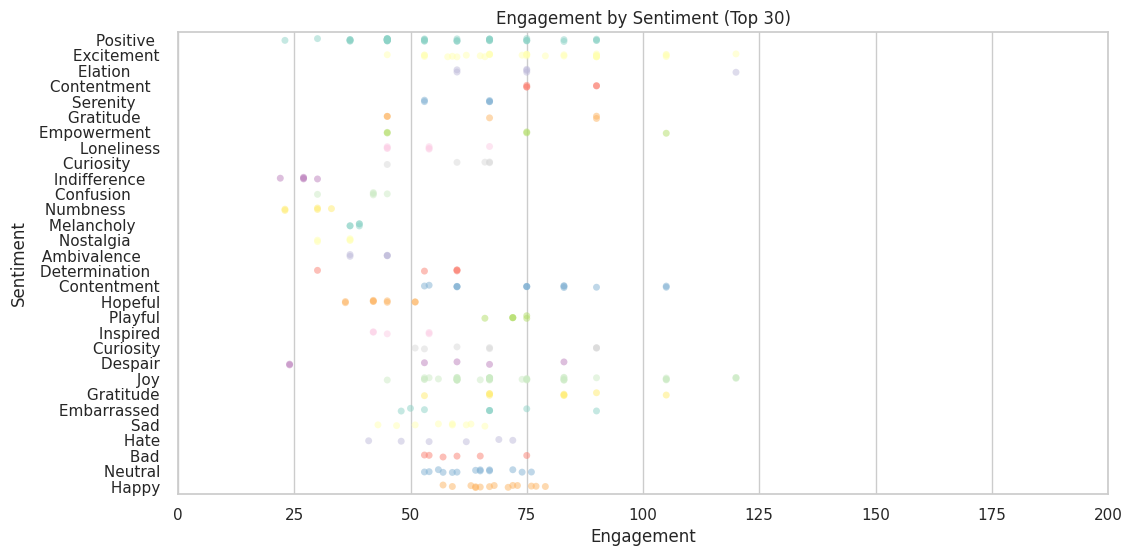

In [ ]:
# -------------------------------
# 6. Engagement vs. Sentiment Scatter (Top 30 only)
# -------------------------------
top_30 = df['Sentiment'].value_counts().nlargest(30).index
filtered = df[df['Sentiment'].isin(top_30)]
sns.stripplot(data=filtered, x='Engagement', y='Sentiment', alpha=0.5, jitter=True, palette='Set3')
plt.title("Engagement by Sentiment (Top 30)")
plt.xlim(0, 200)
plt.show()

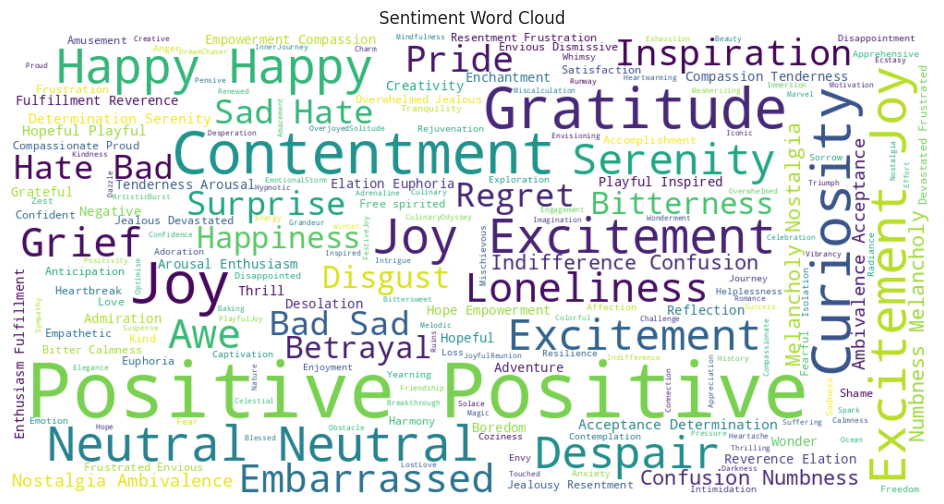

In [ ]:
# -------------------------------
# 7. Sentiment Word Cloud
# -------------------------------
wc = WordCloud(width=1000, height=500, background_color='white').generate(' '.join(df['Sentiment'].astype(str)))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Sentiment Word Cloud")
plt.show()

<ipython-input-90-ddc4929f8bfd>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tag_df, x='Count', y='Hashtag', palette='rocket')


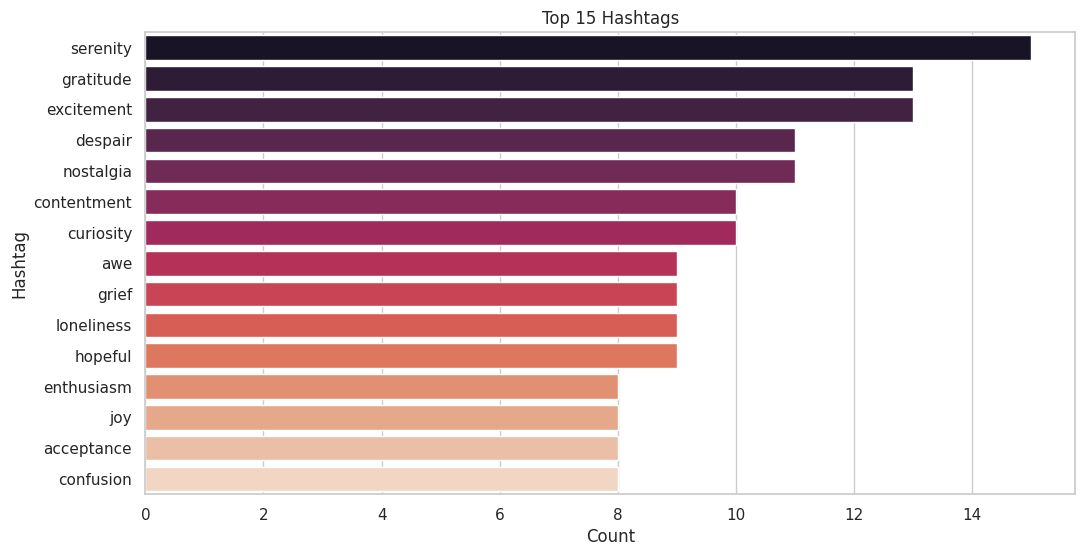

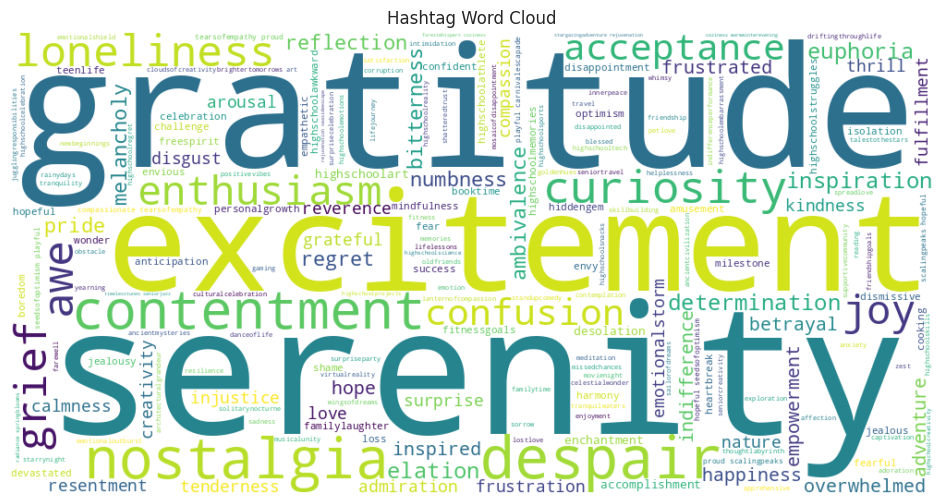

In [ ]:
# -------------------------------
# 8. Hashtag Word Cloud & Bar Chart
# -------------------------------
hashtags = df['Hashtags'].dropna().astype(str).str.split()
flat_tags = [tag.lower().strip('#') for sublist in hashtags for tag in sublist]
top_tags = Counter(flat_tags).most_common(15)

# Bar Chart
tag_df = pd.DataFrame(top_tags, columns=['Hashtag', 'Count'])
sns.barplot(data=tag_df, x='Count', y='Hashtag', palette='rocket')
plt.title("Top 15 Hashtags")
plt.show()

# Word Cloud
wc2 = WordCloud(width=1000, height=500, background_color='white').generate(' '.join(flat_tags))
plt.imshow(wc2, interpolation='bilinear')
plt.axis('off')
plt.title("Hashtag Word Cloud")
plt.show()

<ipython-input-91-a09114a2a32c>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_users.values, y=top_users.index, palette='crest')


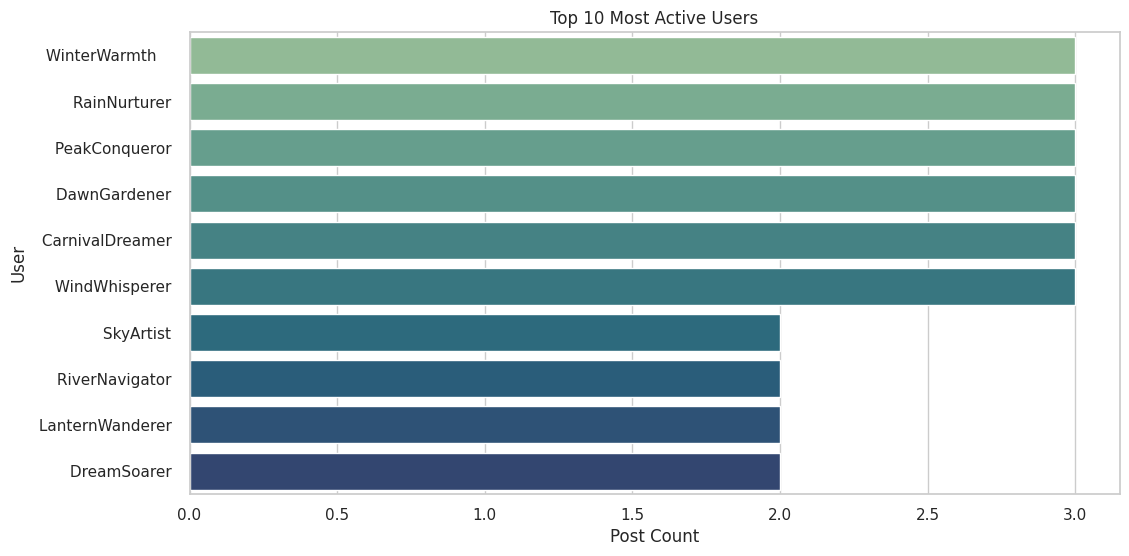

In [ ]:
# -------------------------------
# 9. Top 10 Most Active Users
# -------------------------------
top_users = df['User'].value_counts().nlargest(10)
sns.barplot(x=top_users.values, y=top_users.index, palette='crest')
plt.title("Top 10 Most Active Users")
plt.xlabel("Post Count")
plt.show()

In [ ]:
# -------------------------------
# 11. Sentiment Polarity Distribution
# -------------------------------
sns.histplot(df['Polarity'], bins=30, kde=True, color='teal')
plt.title("Sentiment Polarity Distribution")
plt.xlabel("Polarity")
plt.ylabel("Frequency")
plt.show()

KeyError: 'Polarity'

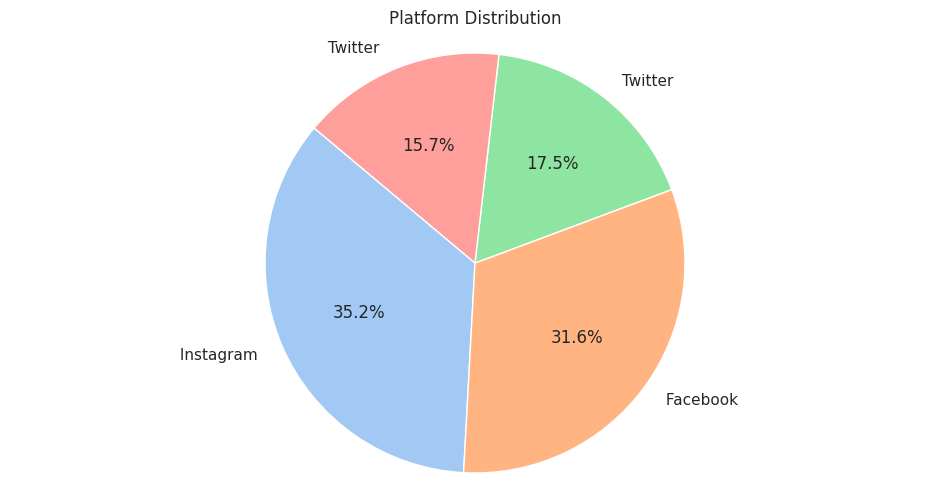

In [ ]:
# -------------------------------
# 12. Platform Distribution Pie Chart
# -------------------------------
platform_counts = df['Platform'].value_counts()
plt.pie(platform_counts.values, labels=platform_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title("Platform Distribution")
plt.axis('equal')
plt.show()

In [ ]:
# Save clean dataset
df.to_csv("enriched_social_sentiments.csv", index=False)

In [ ]:
# Set visual style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 10)


=== Basic Sentiment Distribution ===
Sentiment_3cat
Neutral     46.7
Positive    37.0
Negative    16.3
Name: proportion, dtype: float64


<ipython-input-103-73454cf10e64>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Sentiment_3cat',


Text(0, 0.5, 'Number of Posts')

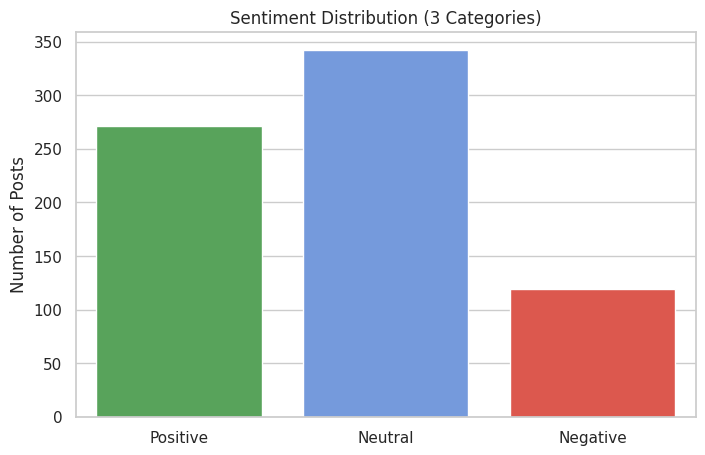

In [ ]:
## 1. Basic Distribution Analysis
print("\n=== Basic Sentiment Distribution ===")
sentiment_dist = df['Sentiment_3cat'].value_counts(normalize=True) * 100
print(sentiment_dist.round(1))

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Sentiment_3cat',
                  order=['Positive', 'Neutral', 'Negative'],
                  palette={'Positive':'#4CAF50', 'Neutral':'#6495ED', 'Negative':'#F44336'})
plt.title("Sentiment Distribution (3 Categories)")
plt.xlabel("")
plt.ylabel("Number of Posts")

In [ ]:
# Add percentage labels
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height()/total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()


=== Engagement Metrics ===
                     mean  median  count
Sentiment_3cat                          
Negative        56.268908    54.0    119
Neutral         62.754386    60.0    342
Positive        70.073801    67.0    271


<ipython-input-107-67588453486a>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Sentiment_3cat', y='Engagement',


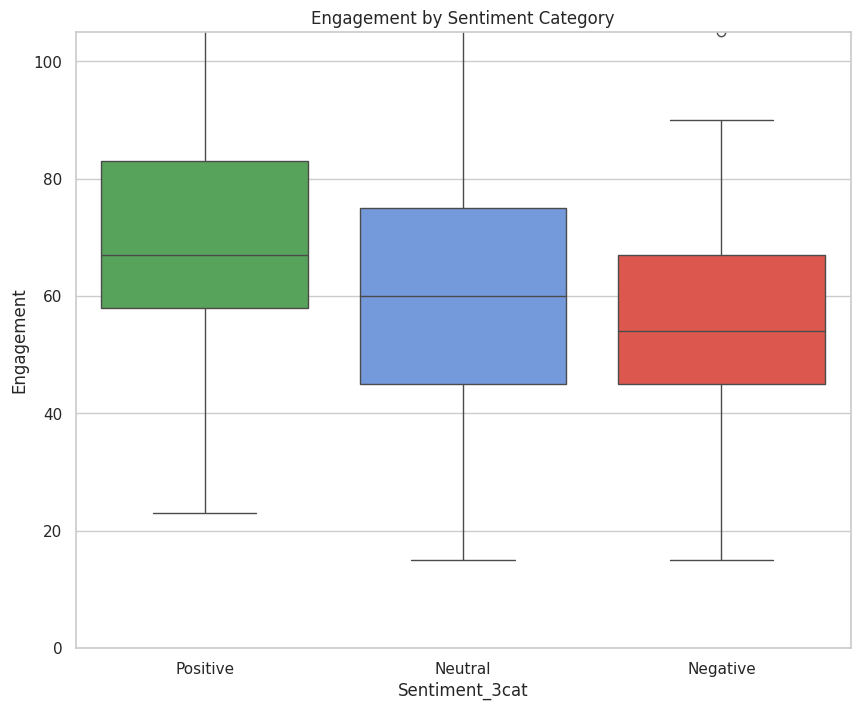

In [ ]:
## 2. Engagement Analysis
print("\n=== Engagement Metrics ===")
engagement_stats = df.groupby('Sentiment_3cat')['Engagement'].agg(['mean', 'median', 'count'])
print(engagement_stats)

plt.figure(figsize=(10, 8))
sns.boxplot(data=df, x='Sentiment_3cat', y='Engagement',
           order=['Positive', 'Neutral', 'Negative'],
           palette={'Positive':'#4CAF50', 'Neutral':'#6495ED', 'Negative':'#F44336'})
plt.title("Engagement by Sentiment Category")
plt.ylim(0, df['Engagement'].quantile(0.95))  # Remove extreme outliers
plt.show()

<Figure size 1200x600 with 0 Axes>

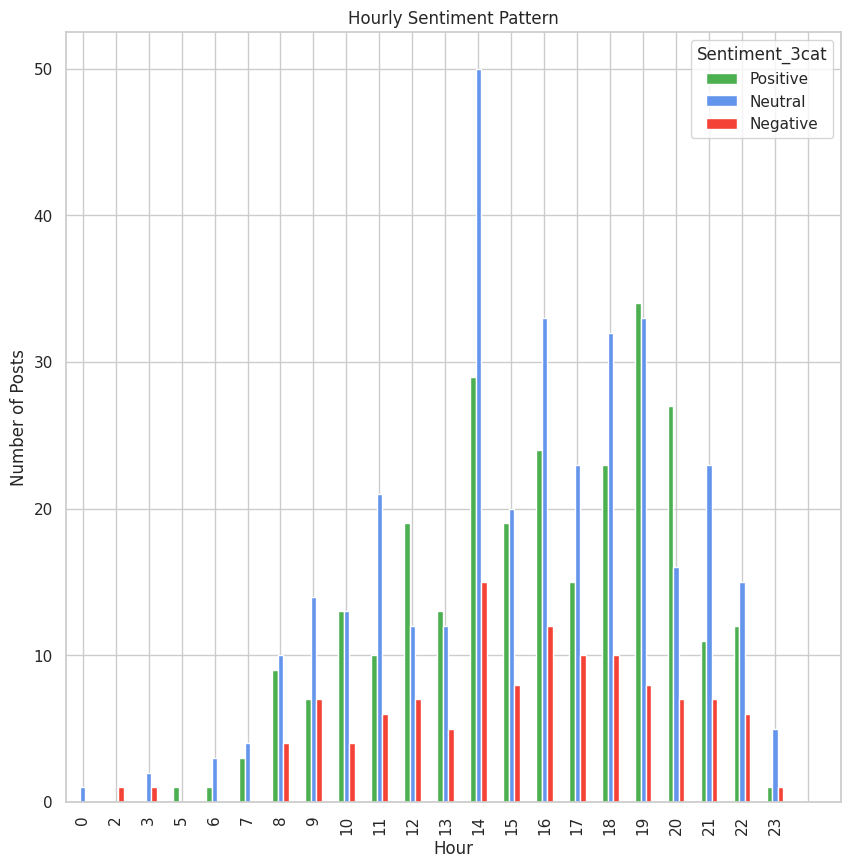

In [ ]:
## 3. Temporal Analysis
df['Hour'] = df['Timestamp'].dt.hour
df['Day'] = df['Timestamp'].dt.day_name()

# Hourly pattern
plt.figure(figsize=(12, 6))
hourly = df.groupby(['Hour', 'Sentiment_3cat']).size().unstack()
hourly[['Positive', 'Neutral', 'Negative']].plot(
    kind='bar',
    color=['#4CAF50', '#6495ED', '#F44336']
)
plt.title("Hourly Sentiment Pattern")
plt.ylabel("Number of Posts")
plt.xticks(range(0, 24))
plt.show()

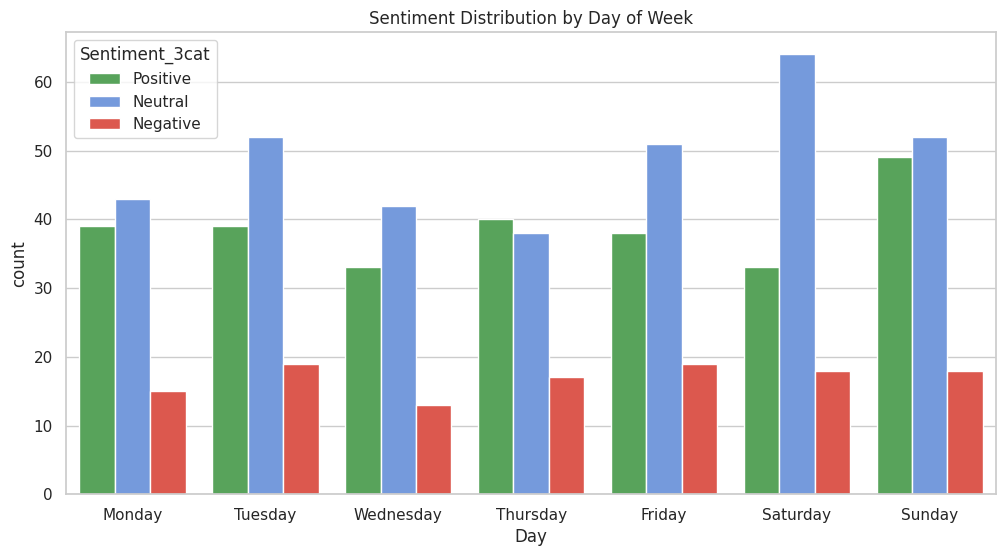

In [ ]:
# Daily pattern
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Day', hue='Sentiment_3cat', order=day_order,
             hue_order=['Positive', 'Neutral', 'Negative'],
             palette={'Positive':'#4CAF50', 'Neutral':'#6495ED', 'Negative':'#F44336'})
plt.title("Sentiment Distribution by Day of Week")
plt.show()

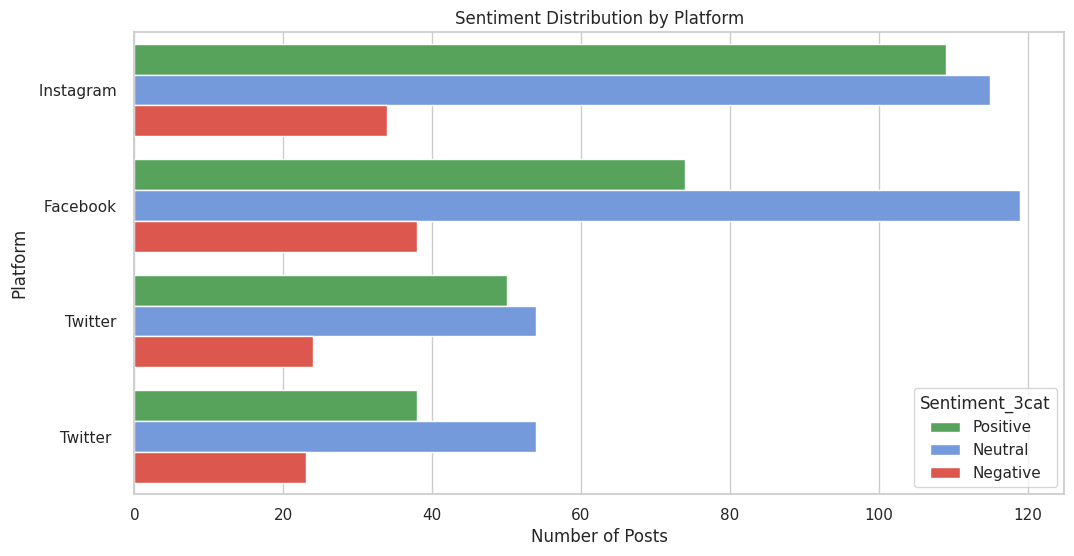

In [ ]:
## 4. Platform Comparison
plt.figure(figsize=(12, 6))
platform_order = df['Platform'].value_counts().index  # Sort by post count
sns.countplot(data=df, y='Platform', hue='Sentiment_3cat', order=platform_order,
             hue_order=['Positive', 'Neutral', 'Negative'],
             palette={'Positive':'#4CAF50', 'Neutral':'#6495ED', 'Negative':'#F44336'})
plt.title("Sentiment Distribution by Platform")
plt.xlabel("Number of Posts")
plt.show()


Top 10 Positive Hashtags:
#joy: 7 posts
#enthusiasm: 6 posts
#awe: 6 posts
#serenity: 6 posts
#nostalgia: 6 posts
#happiness: 5 posts
#excitement: 5 posts
#contentment: 5 posts
#adventure: 4 posts
#love: 4 posts


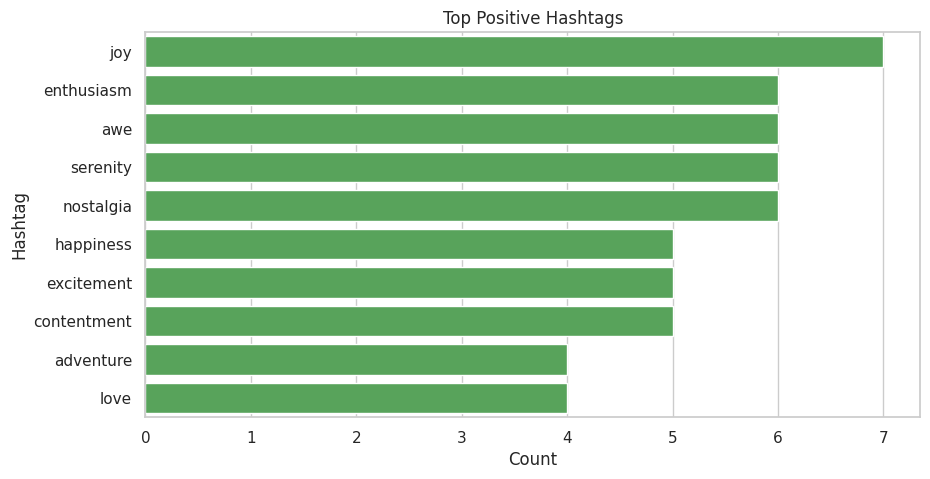


Top 10 Negative Hashtags:
#grief: 7 posts
#despair: 5 posts
#frustrated: 5 posts
#gratitude: 3 posts
#bitterness: 3 posts
#regret: 3 posts
#loneliness: 3 posts
#fearful: 3 posts
#betrayal: 3 posts
#reflection: 2 posts


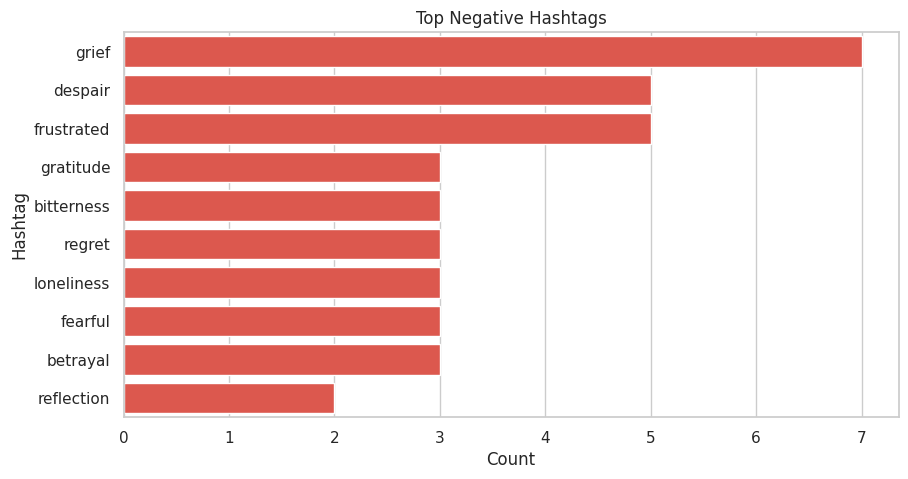

In [ ]:
## 5. Hashtag Analysis (Top 10 for each sentiment)
def get_top_hashtags(sentiment, n=10):
    hashtags = df[df['Sentiment_3cat']==sentiment]['Hashtags'].dropna().astype(str).str.split()
    flat_tags = [tag.lower().strip('#') for sublist in hashtags for tag in sublist]
    return Counter(flat_tags).most_common(n)

for sentiment in ['Positive', 'Negative']:
    top_tags = get_top_hashtags(sentiment)
    print(f"\nTop 10 {sentiment} Hashtags:")
    for tag, count in top_tags:
        print(f"#{tag}: {count} posts")

    # Visualization
    tag_df = pd.DataFrame(top_tags, columns=['Hashtag', 'Count'])
    plt.figure(figsize=(10, 5))
    sns.barplot(data=tag_df, x='Count', y='Hashtag',
               color='#4CAF50' if sentiment=='Positive' else '#F44336')
    plt.title(f"Top {sentiment} Hashtags")
    plt.show()

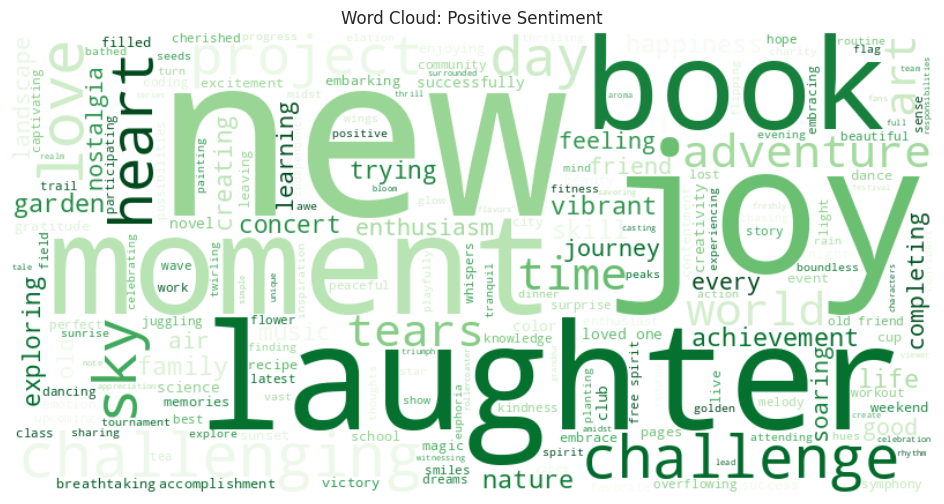

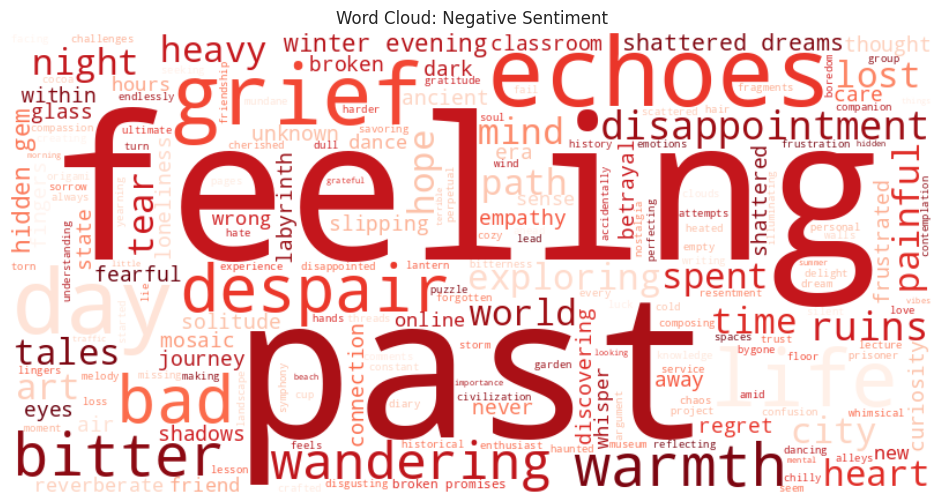

In [ ]:
## 6. Word Clouds by Sentiment
def generate_wordcloud(sentiment):
    text = ' '.join(df[df['Sentiment_3cat']==sentiment]['cleaned_text'])
    color = 'Greens' if sentiment=='Positive' else 'Reds'
    wordcloud = WordCloud(width=800, height=400,
                         background_color='white',
                         colormap=color).generate(text)
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud: {sentiment} Sentiment")
    plt.show()

generate_wordcloud('Positive')
generate_wordcloud('Negative')

<Figure size 1400x700 with 0 Axes>

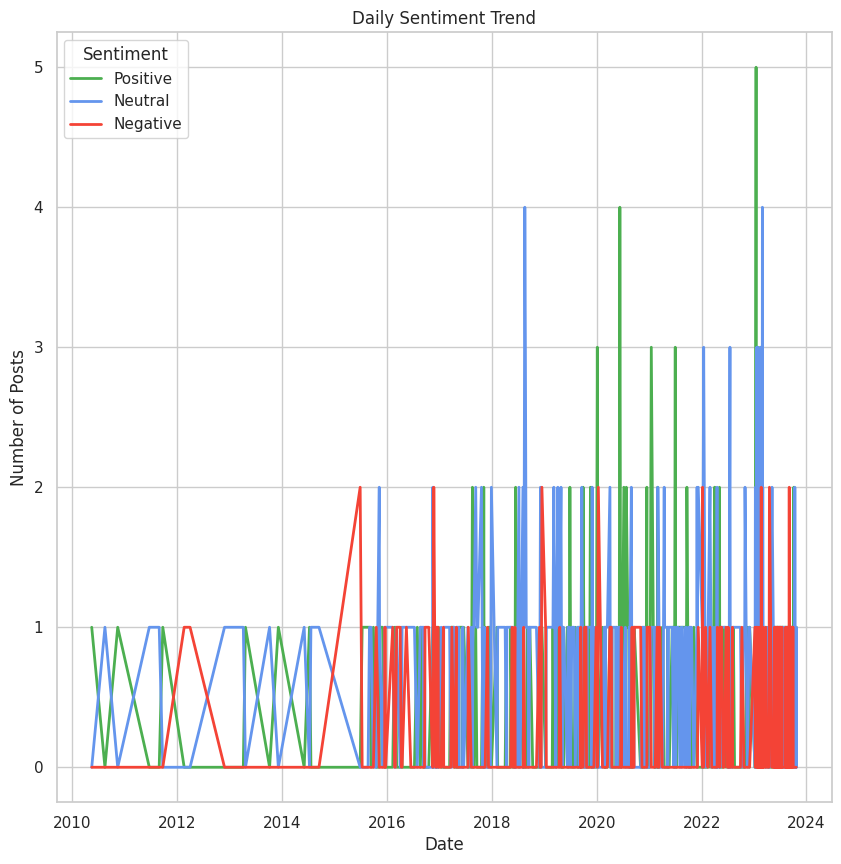

In [ ]:
## 7. Advanced: Sentiment Over Time
df['Date'] = df['Timestamp'].dt.date
daily_sentiment = df.groupby(['Date', 'Sentiment_3cat']).size().unstack().fillna(0)

plt.figure(figsize=(14, 7))
daily_sentiment[['Positive', 'Neutral', 'Negative']].plot(
    color=['#4CAF50', '#6495ED', '#F44336'],
    linewidth=2
)
plt.title("Daily Sentiment Trend")
plt.ylabel("Number of Posts")
plt.xlabel("Date")
plt.legend(title='Sentiment')
plt.show()

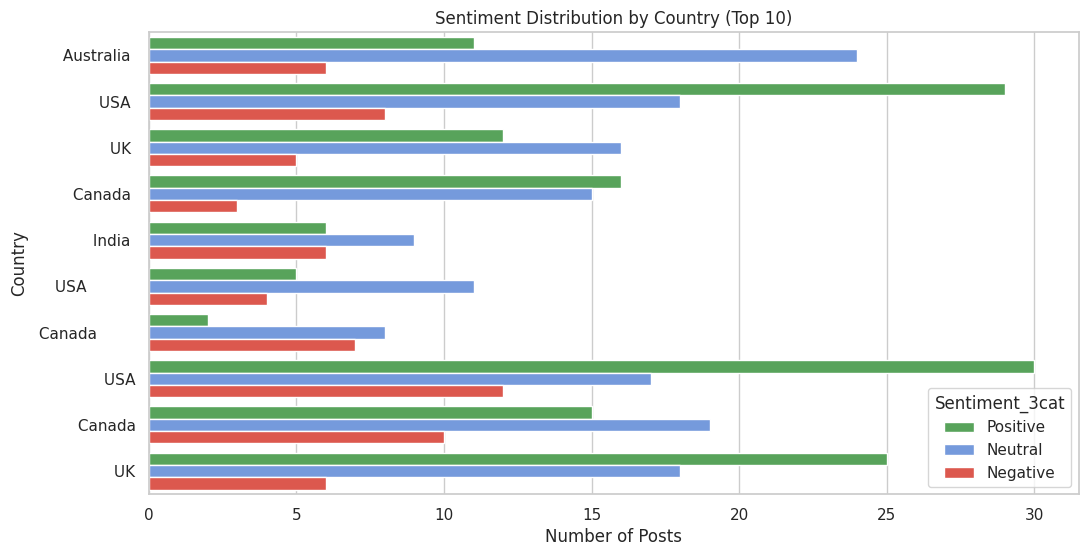

In [ ]:
## 8. Sentiment by Country (Top 10 countries)
top_countries = df['Country'].value_counts().head(10).index
plt.figure(figsize=(12, 6))
sns.countplot(data=df[df['Country'].isin(top_countries)],
             y='Country', hue='Sentiment_3cat',
             hue_order=['Positive', 'Neutral', 'Negative'],
             palette={'Positive':'#4CAF50', 'Neutral':'#6495ED', 'Negative':'#F44336'})
plt.title("Sentiment Distribution by Country (Top 10)")
plt.xlabel("Number of Posts")
plt.show()